# 🛢️ Crude Oil Prices & World Events (2005–2024)

**How do geopolitical shocks, financial crises, and supply decisions move the price of oil?**

This notebook maps every major macro event of the last two decades onto the WTI Crude Oil price chart — turning a noisy time series into a readable story.

---
*Data: Yahoo Finance (WTI Continuous Futures — `CL=F`) · Visualisation: Matplotlib*

## 1 · Setup & Data

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ── Download WTI Crude Oil Futures 
raw = yf.download('CL=F', start='2005-01-01', end='2024-12-31',
                  auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

wti = raw[['Close']].copy()
wti.columns = ['Price']
wti = wti[wti['Price'] > 0].dropna()   # remove the April 2020 negative-price anomaly

print(f'WTI data: {len(wti):,} trading days  '
      f'({wti.index[0].date()} → {wti.index[-1].date()})')
print(f'Price range: ${wti.Price.min():.1f}  →  ${wti.Price.max():.1f}')

WTI data: 5,028 trading days  (2005-01-03 → 2024-12-30)
Price range: $10.0  →  $145.3


## 2 · Event Catalogue

Each event is tagged with:
- **date** — the approximate market-impact date
- **label** — short description shown on the chart
- **type** — drives the colour coding

| Type | Meaning |
|---|---|
| `crisis` | Financial or economic shock |
| `geopolitical` | War, sanctions, political upheaval |
| `opec` | OPEC / supply-side decision |
| `pandemic` | COVID-19 related |
| `energy` | Energy-market structural event |

In [ ]:
EVENTS = [
    # ── 2005–2009 
    ('2005-08-29', 'Hurricane\nKatrina',          'geopolitical'),
    ('2008-07-03', 'WTI all-time\nhigh $147',     'crisis'),
    ('2008-09-15', 'Lehman\nBrothers',            'crisis'),
    # ── 2010–2014
    ('2010-12-17', 'Arab Spring\nbegins',         'geopolitical'),
    ('2011-03-17', 'Libya civil\nwar',            'geopolitical'),
    ('2011-05-02', 'Bin Laden\nkilled',           'geopolitical'),
    ('2014-06-20', 'ISIS takes\nMosul',           'geopolitical'),
    # ── 2014–2016 price collapse 
    ('2014-11-27', 'OPEC holds\nproduction',      'opec'),
    ('2016-01-16', 'Iran sanctions\nlifted',      'geopolitical'),
    ('2016-11-30', 'OPEC first\ncut deal',        'opec'),
    # ── 2018–2019 
    ('2018-05-08', 'US exits\nIran deal',         'geopolitical'),
    ('2019-09-14', 'Saudi Aramco\nattack',        'geopolitical'),
    # ── COVID era 
    ('2020-03-06', 'OPEC+ talks\ncollapse',       'pandemic'),
    ('2020-03-11', 'WHO declares\npandemic',      'pandemic'),
    ('2021-03-23', 'Suez Canal\nblockage',        'geopolitical'),
    # ── 2022 Ukraine
    ('2022-02-24', 'Russia invades\nUkraine',     'geopolitical'),
    ('2022-03-08', 'WTI peaks\n$130',             'energy'),
    ('2022-06-09', 'EU Russian oil\nembargo',     'geopolitical'),
    # ── 2023–2024 
    ('2023-10-07', 'Hamas attack\non Israel',     'geopolitical'),
    ('2024-04-01', 'OPEC+ extends\ncuts to Q3',   'opec'),
]

COLORS = {
    'crisis':       '#E53935',
    'geopolitical': '#FB8C00',
    'opec':         '#8E24AA',
    'pandemic':     '#00ACC1',
    'energy':       '#43A047',
}

events_df = pd.DataFrame(EVENTS, columns=['date', 'label', 'type'])
events_df['date'] = pd.to_datetime(events_df['date'])
print(f'{len(events_df)} events loaded across {events_df.type.nunique()} categories')

20 events loaded across 5 categories


## 3 · Main Chart

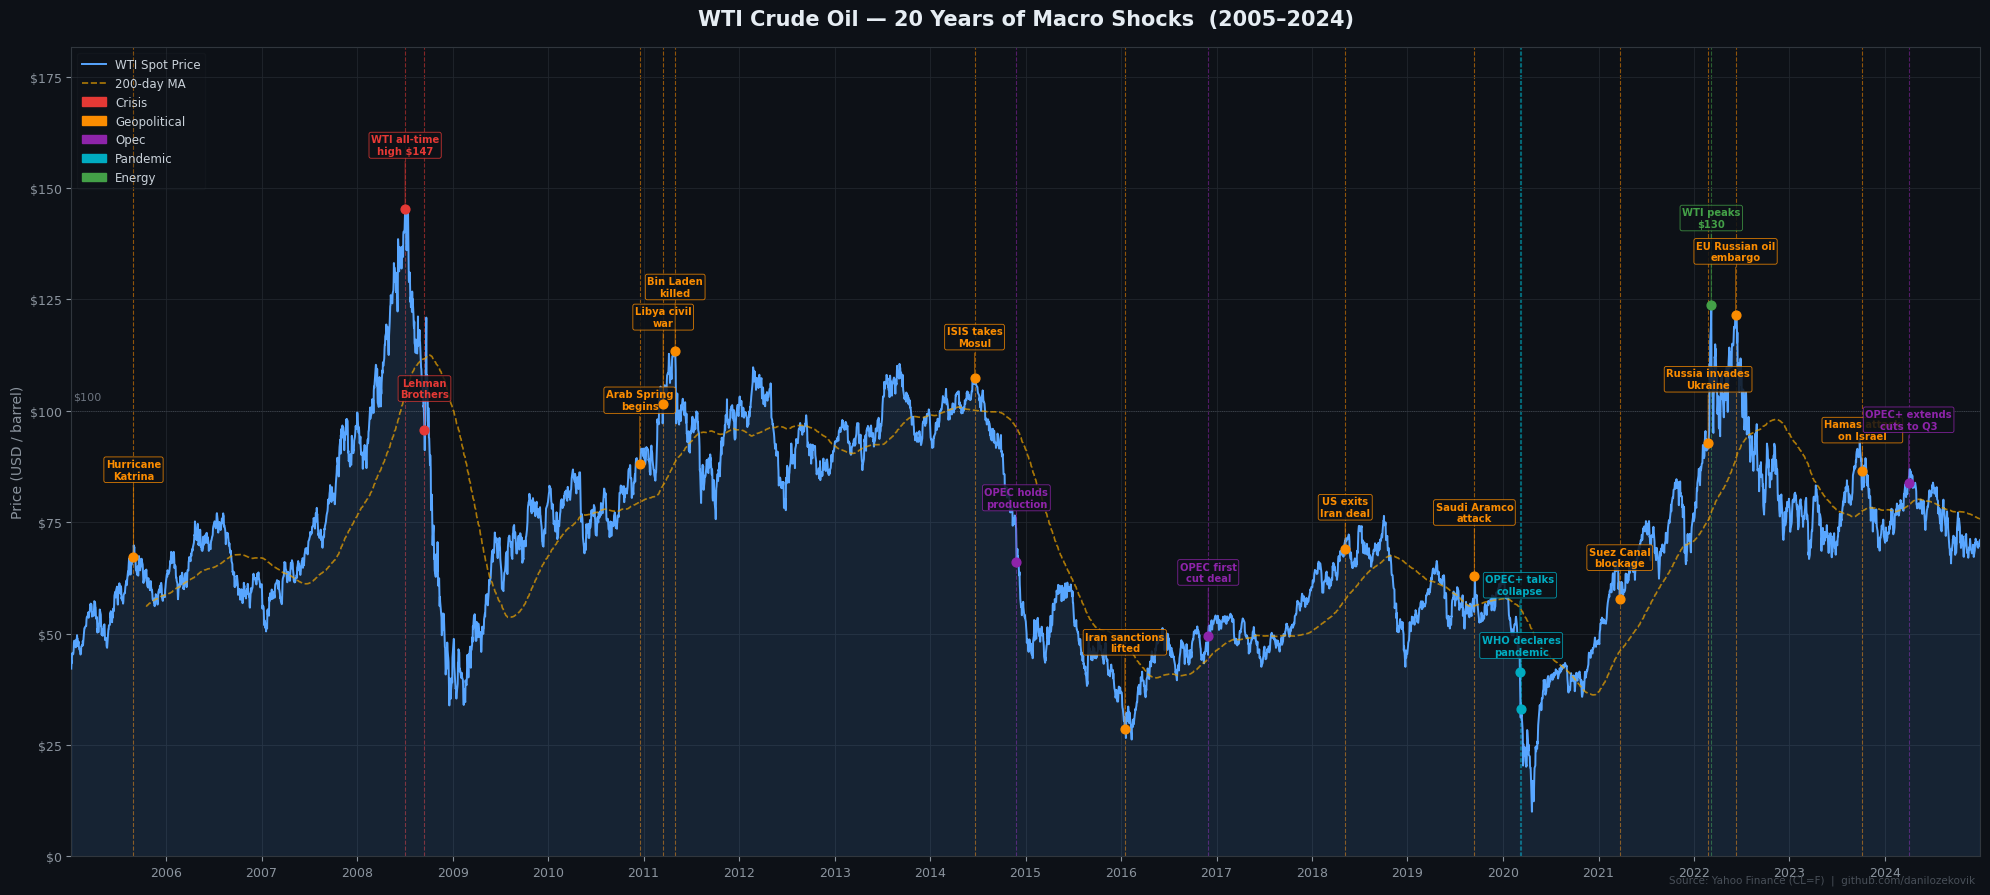

Chart saved → wti_world_events.png


In [4]:
def usd_fmt(x, pos):
    return f'${x:.0f}'

def nearest_price(date):
    idx = wti.index.searchsorted(date)
    idx = min(idx, len(wti) - 1)
    return wti.iloc[idx]['Price']


fig, ax = plt.subplots(figsize=(20, 9))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Price line + fill
ax.plot(wti.index, wti['Price'],
        color='#58A6FF', linewidth=1.4, zorder=3, label='WTI Spot Price')
ax.fill_between(wti.index, wti['Price'], alpha=0.12, color='#58A6FF', zorder=2)

# 200-day MA
ma200 = wti['Price'].rolling(200).mean()
ax.plot(wti.index, ma200,
        color='#F0A500', linewidth=1.2, linestyle='--',
        alpha=0.7, zorder=3, label='200-day MA')

# $100 reference
ax.axhline(100, color='#6E7681', linewidth=0.6, linestyle=':', alpha=0.5)
ax.text(wti.index[5], 102, '$100', color='#6E7681', fontsize=8, va='bottom')

# Event annotations
y_offsets = [55, 38, 22, 38, 55, 38, 22, 38]

for i, row in events_df.iterrows():
    if row['date'] < wti.index[0] or row['date'] > wti.index[-1]:
        continue
    price = nearest_price(row['date'])
    color = COLORS[row['type']]
    y_off = y_offsets[i % len(y_offsets)]

    ax.axvline(row['date'], color=color, linewidth=0.8,
               linestyle='--', alpha=0.55, zorder=1)
    ax.scatter(row['date'], price, color=color, s=40, zorder=5)
    ax.annotate(
        row['label'],
        xy=(row['date'], price),
        xytext=(0, y_off),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=7.2, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color=color, alpha=0.5, lw=0.8),
        bbox=dict(boxstyle='round,pad=0.2', fc='#0D1117',
                  ec=color, lw=0.6, alpha=0.85),
    )

# Styling
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')
ax.yaxis.set_major_formatter(FuncFormatter(usd_fmt))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(colors='#8B949E', labelsize=9)
ax.grid(True, color='#21262D', linewidth=0.6, zorder=0)
ax.set_xlim(wti.index[0], wti.index[-1])
ax.set_ylim(0, wti['Price'].max() * 1.25)
ax.set_ylabel('Price (USD / barrel)', color='#8B949E', fontsize=10)

# Legend
type_patches = [mpatches.Patch(color=c, label=t.capitalize())
                for t, c in COLORS.items()]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(
    handles=line_handles + type_patches,
    labels=line_labels + [p.get_label() for p in type_patches],
    loc='upper left', framealpha=0.15,
    facecolor='#161B22', edgecolor='#30363D',
    fontsize=8.5, labelcolor='#C9D1D9',
)

ax.set_title(
    'WTI Crude Oil — 20 Years of Macro Shocks  (2005–2024)',
    color='#E6EDF3', fontsize=15, fontweight='bold', pad=16,
)
fig.text(0.99, 0.01,
         'Source: Yahoo Finance (CL=F)  |  github.com/danilozekovik',
         ha='right', va='bottom', color='#484F58', fontsize=7.5)

plt.tight_layout()
plt.savefig('wti_world_events.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Chart saved → wti_world_events.png')

## 4 · Key Takeaways

A quick look at the chart reveals three structural regimes:

**2005–2008 — The commodity super-cycle.** Strong global demand growth (China, India) pushed WTI from ~$50 to an all-time high of **$147 in July 2008**. The Lehman collapse wiped out half that gain in under six months.

**2014–2016 — The shale revolution kills the OPEC floor.** US shale production doubled between 2010 and 2014. When OPEC refused to cut in November 2014, prices collapsed from $100 to below $30 — the fastest oil crash in history outside of a recession.

**2020–2022 — Pandemic shock & war spike.** Demand destruction from COVID-19 sent WTI briefly **below zero** (April 20, 2020 — a settlement anomaly driven by storage capacity limits). The subsequent recovery, accelerated by the Russian invasion of Ukraine in February 2022, pushed prices back above $130.

---

**Pattern to note:** Geopolitical events (orange) create sharp, short-lived spikes. Supply decisions by OPEC (purple) drive slower but more persistent trends. Financial crises (red) produce the deepest and fastest drawdowns.

## 5 · Bonus — Peak & Trough Summary

In [6]:
regimes = [
    ('2005-01-01', '2008-07-11', 'Commodity super-cycle peak'),
    ('2008-07-11', '2009-02-18', 'Lehman crash'),
    ('2009-02-18', '2011-04-29', 'Recovery'),
    ('2011-04-29', '2016-01-20', '2014-16 shale collapse'),
    ('2016-01-20', '2018-10-03', 'Recovery II'),
    ('2018-10-03', '2020-04-01', 'COVID crash'),
    ('2020-04-01', '2022-03-07', 'Post-COVID + Ukraine spike'),
    ('2022-03-07', '2024-12-31', 'Normalisation'),
]

rows = []
for start, end, name in regimes:
    mask  = (wti.index >= start) & (wti.index <= end)
    chunk = wti.loc[mask, 'Price']
    if len(chunk) < 2:
        continue
    chg = (chunk.iloc[-1] / chunk.iloc[0] - 1) * 100
    rows.append({
        'Period':     name,
        'Start':      start[:7],
        'End':        end[:7],
        'Start ($)':  f"{chunk.iloc[0]:.1f}",
        'End ($)':    f"{chunk.iloc[-1]:.1f}",
        'Change':     f"{chg:+.1f}%",
    })

summary = pd.DataFrame(rows).set_index('Period')

def color_change(val):
    color = '#2ea043' if val.startswith('+') else '#f85149'
    return f'color: {color}; font-weight: bold'

summary.style \
    .map(color_change, subset=['Change']) \
    .set_properties(**{'text-align': 'right'}) \
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'left'), ('font-weight', 'bold')]
    }])

,Start,End,Start ($),End ($),Change
Period,,,,,
Commodity super-cycle peak,2005-01,2008-07,42.1,145.1,+244.4%
Lehman crash,2008-07,2009-02,145.1,34.6,-76.1%
Recovery,2009-02,2011-04,34.6,113.9,+229.1%
2014-16 shale collapse,2011-04,2016-01,113.9,26.5,-76.7%
Recovery II,2016-01,2018-10,26.5,76.4,+187.8%
COVID crash,2018-10,2020-04,76.4,20.3,-73.4%
Post-COVID + Ukraine spike,2020-04,2022-03,20.3,119.4,+487.9%
Normalisation,2022-03,2024-12,119.4,71.0,-40.5%
